In [ ]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 18.0 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from collections import defaultdict
from captum.attr import LayerGradCam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Data Loading

In [ ]:
clean_transform = transforms.Compose([
    transforms.ToTensor(),
])

# Shifted test data — aggressive enough to cause real failure
shift_transform = transforms.Compose([
    transforms.RandomRotation(75),          # was 30 — now 75 degrees
    transforms.GaussianBlur(kernel_size=7), # was 3 — now 7
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=clean_transform
)
test_dataset_clean = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=clean_transform
)
test_dataset_shift = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=shift_transform
)

train_loader       = torch.utils.data.DataLoader(train_dataset,       batch_size=64, shuffle=True)
test_loader_clean  = torch.utils.data.DataLoader(test_dataset_clean,  batch_size=1,  shuffle=False)
test_loader_shift  = torch.utils.data.DataLoader(test_dataset_shift,  batch_size=1,  shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 141MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 14.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 127MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]


Model


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  # conv layer 1 — index 0
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), # conv layer 2 — index 3
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),      # correct: 64 channels × 7×7 spatial
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = CNN().to(device)

Training

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/5 — Loss: {running_loss/len(train_loader):.4f}")


Epoch 1/5 — Loss: 0.1826
Epoch 2/5 — Loss: 0.0515
Epoch 3/5 — Loss: 0.0350
Epoch 4/5 — Loss: 0.0266
Epoch 5/5 — Loss: 0.0206


Evaluate


In [ ]:
def evaluate(model, loader, label=""):
    model.eval()
    correct, total = 0, 0
    misclassified = []
    with torch.no_grad():
        for image, lbl in loader:
            image, lbl = image.to(device), lbl.to(device)
            output = model(image)
            _, pred = torch.max(output, 1)
            total += 1
            if pred == lbl:
                correct += 1
            else:
                misclassified.append((image, lbl, pred))
    acc = correct / total
    print(f"{label} Accuracy: {acc:.4f} ({correct}/{total})")
    return acc, misclassified

clean_acc,  misclassified_clean  = evaluate(model, test_loader_clean, "Clean")
shifted_acc, misclassified_shift = evaluate(model, test_loader_shift, "Shifted")

print(f"\nAccuracy drop: {(clean_acc - shifted_acc)*100:.2f}%")
print(f"Misclassified under shift: {len(misclassified_shift)}")

Clean Accuracy: 0.9901 (9901/10000)
Shifted Accuracy: 0.6430 (6430/10000)

Accuracy drop: 34.71%
Misclassified under shift: 3570


D(k) — YOUR LOCALITY METRIC

In [ ]:
layer_gc_1 = LayerGradCam(model, model.conv[0])  # conv layer 1
layer_gc_2 = LayerGradCam(model, model.conv[3])  # conv layer 2

def compute_dk(model, gc_layer1, gc_layer2, clean_image, shifted_image, target_class):
    """
    Computes D(k) at layer 1 and layer 2.
    D(k) = norm(GradCAM_shifted - GradCAM_clean) at layer k.
    Large D(k) = spurious signal has entered this layer strongly.
    """
    clean_image   = clean_image.to(device).requires_grad_(True)
    shifted_image = shifted_image.to(device).requires_grad_(True)

    attr_clean_1   = gc_layer1.attribute(clean_image,   target=target_class)
    attr_shifted_1 = gc_layer1.attribute(shifted_image, target=target_class)

    attr_clean_2   = gc_layer2.attribute(clean_image,   target=target_class)
    attr_shifted_2 = gc_layer2.attribute(shifted_image, target=target_class)

    D1 = (attr_shifted_1 - attr_clean_1).norm().item()
    D2 = (attr_shifted_2 - attr_clean_2).norm().item()

    return D1, D2

# Compute D(k) on first 50 misclassified shifted samples
print("\nComputing D(k) locality scores...")
d1_scores, d2_scores = [], []

for i, (shifted_img, lbl, pred) in enumerate(misclassified_shift[:50]):
    clean_img = test_dataset_clean[i][0].unsqueeze(0)
    true_class = lbl.item()

    D1, D2 = compute_dk(model, layer_gc_1, layer_gc_2, clean_img, shifted_img, true_class)
    d1_scores.append(D1)
    d2_scores.append(D2)

avg_D1 = sum(d1_scores) / len(d1_scores)
avg_D2 = sum(d2_scores) / len(d2_scores)

print(f"Average D(1) — conv layer 1: {avg_D1:.4f}")
print(f"Average D(2) — conv layer 2: {avg_D2:.4f}")

if avg_D2 > avg_D1:
    print("→ Spurious signal is GROWING through layers — domino effect confirmed")
elif avg_D2 < avg_D1:
    print("→ Spurious signal is SHRINKING through layers — deeper layers more robust")
else:
    print("→ Signal is stable across layers")


Computing D(k) locality scores...
Average D(1) — conv layer 1: 0.0913
Average D(2) — conv layer 2: 0.3489
→ Spurious signal is GROWING through layers — domino effect confirmed


Plot D(k)

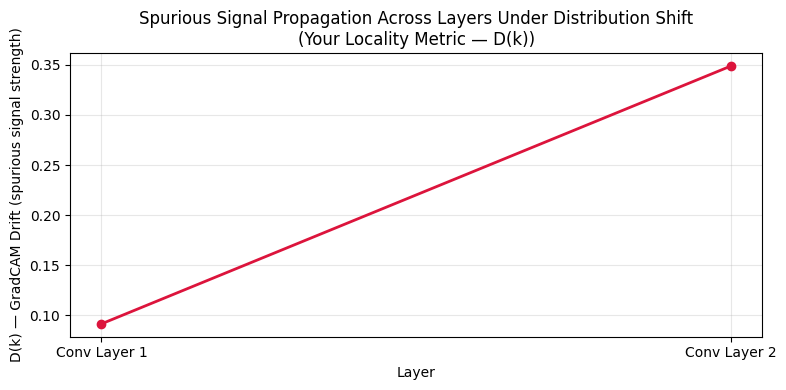

Plot saved as dk_locality_metric.png


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot([1, 2], [avg_D1, avg_D2], marker='o', linewidth=2, color='crimson')
plt.xticks([1, 2], ['Conv Layer 1', 'Conv Layer 2'])
plt.ylabel('D(k) — GradCAM Drift (spurious signal strength)')
plt.xlabel('Layer')
plt.title('Spurious Signal Propagation Across Layers Under Distribution Shift\n(Your Locality Metric — D(k))')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dk_locality_metric.png", dpi=150)
plt.show()
print("Plot saved as dk_locality_metric.png")


Grad-CAM Visualisation


Visualising GradCAM on first 5 misclassified shifted samples...


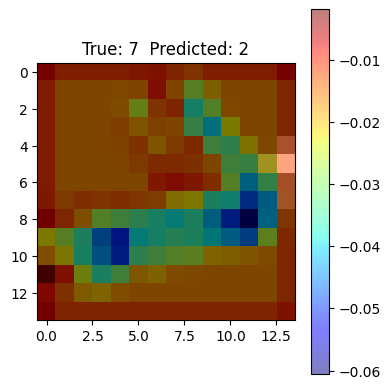

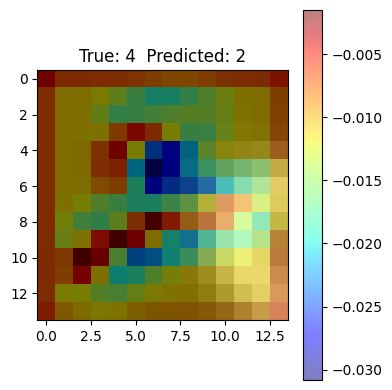

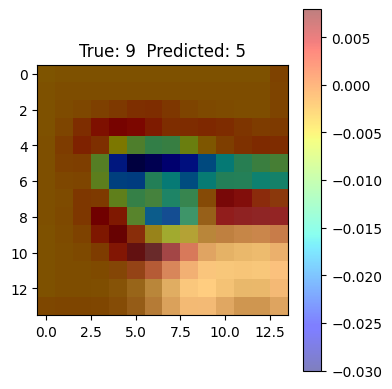

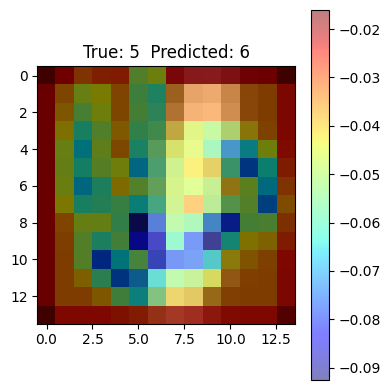

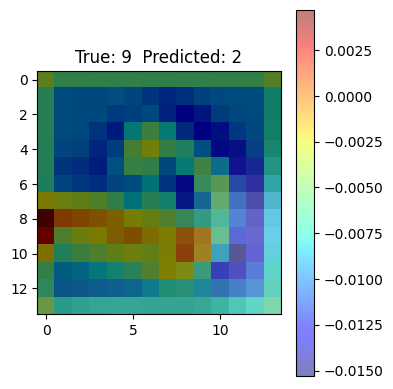

In [ ]:
print("\nVisualising GradCAM on first 5 misclassified shifted samples...")

for i in range(min(5, len(misclassified_shift))):
    image, lbl, pred = misclassified_shift[i]
    image = image.to(device).requires_grad_(True)

    attr = layer_gc_2.attribute(image, target=pred.item())
    attr_np = attr.cpu().detach().numpy()[0, 0]
    img_np  = image.cpu().detach().numpy()[0, 0]

    plt.figure(figsize=(4, 4))
    plt.imshow(img_np, cmap="gray")
    plt.imshow(attr_np, cmap="jet", alpha=0.5)
    plt.title(f"True: {lbl.item()}  Predicted: {pred.item()}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


Confidence Based Containment

In [ ]:

def predict_with_confidence(model, image, threshold=0.7):
    model.eval()
    with torch.no_grad():
        output = model(image)
        probs = F.softmax(output, dim=1)
        confidence, pred = torch.max(probs, 1)
    if confidence.item() < threshold:
        return "REJECT", confidence.item()
    return pred.item(), confidence.item()

def entropy(probs):
    return -torch.sum(probs * torch.log(probs + 1e-9), dim=1)

def is_ood(model, image, threshold=1.5):
    model.eval()
    with torch.no_grad():
        output = model(image)
        probs = F.softmax(output, dim=1)
    return entropy(probs).item() > threshold

# Single clean loop — no accumulation bug
results = []
correct_shift, total_shift = 0, 0
ood_count, low_conf_count, accepted_count = 0, 0, 0

for image, label in test_loader_shift:
    image = image.to(device)

    if is_ood(model, image):
        results.append(("OOD_REJECT", None, label.item()))
        ood_count += 1
        continue

    result, confidence = predict_with_confidence(model, image)

    if result == "REJECT":
        results.append(("LOW_CONF_REJECT", confidence, label.item()))
        low_conf_count += 1
        continue

    accepted_count += 1
    total_shift += 1
    if result == label.item():
        correct_shift += 1
    results.append((result, confidence, label.item()))

print(f"\n── Containment Summary ──")
print(f"OOD rejected:        {ood_count}")
print(f"Low-conf rejected:   {low_conf_count}")
print(f"Accepted:            {accepted_count}")
print(f"Rejection rate:      {(ood_count + low_conf_count) / len(results):.2%}")
print(f"Shifted accuracy (accepted only): {correct_shift/total_shift:.4f}" if total_shift > 0 else "No accepted samples")



── Containment Summary ──
OOD rejected:        1707
Low-conf rejected:   1922
Accepted:            6371
Rejection rate:      36.29%
Shifted accuracy (accepted only): 0.7875


Error Taxonomy

In [ ]:
confusion_errors = defaultdict(int)
for image, lbl, pred in misclassified_shift:
    confusion_errors[(lbl.item(), pred.item())] += 1

print("\n── Top 10 Confusion Pairs (true → predicted) ──")
for (true, predicted), count in sorted(confusion_errors.items(), key=lambda x: -x[1])[:10]:
    print(f"  {true} → {predicted}: {count} times")


── Top 10 Confusion Pairs (true → predicted) ──
  1 → 2: 244 times
  7 → 2: 232 times
  2 → 7: 215 times
  4 → 2: 214 times
  6 → 5: 159 times
  5 → 6: 143 times
  3 → 7: 121 times
  8 → 4: 121 times
  1 → 7: 117 times
  8 → 2: 105 times


Summary

In [ ]:
print("\n══════════════════════════════════════")
print("RESULTS SUMMARY")
print("══════════════════════════════════════")
print(f"Clean accuracy:          {clean_acc:.4f}")
print(f"Shifted accuracy (raw):  {shifted_acc:.4f}")
print(f"Accuracy drop:           {(clean_acc - shifted_acc)*100:.2f}%")
print(f"Average D(1):            {avg_D1:.4f}")
print(f"Average D(2):            {avg_D2:.4f}")
print(f"Locality Score (D2/D1):  {avg_D2/avg_D1:.4f}  (>1 means signal grows deeper)")
print("══════════════════════════════════════")


══════════════════════════════════════
RESULTS SUMMARY
══════════════════════════════════════
Clean accuracy:          0.9901
Shifted accuracy (raw):  0.6430
Accuracy drop:           34.71%
Average D(1):            0.0913
Average D(2):            0.3489
Locality Score (D2/D1):  3.8235  (>1 means signal grows deeper)
══════════════════════════════════════


In [2]:
!git clone https://github.com/bhuvibhardwaj/ml-failure-proofs.git

Cloning into 'ml-failure-proofs'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 61 (delta 15), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 252.40 KiB | 2.14 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [3]:
!ls

ml-failure-proofs  sample_data


In [4]:
!mv CNN-MNIST-Containment.ipynb ml-failure-proofs/

mv: cannot stat 'CNN-MNIST-Containment.ipynb': No such file or directory


In [5]:
%cd ml-failure-proofs

/content/ml-failure-proofs


In [6]:
!ls

002  003  experiments  README.md


In [8]:
!mkdir -p experiments/004_failure_propagation

In [11]:
!find / -name "*.ipynb" 2>/dev/null | tail -20

/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/Box.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/ErrorBars.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/ItemTable.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/Distribution.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/Bounds.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/Spread.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/Scatter3D.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/Raster.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/RGB.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/reference/elements/plotly/Table.ipynb
/usr/local/l